# Compute $\chi^2$ for the DESI mock-challenge **box** measurements (alternative cosmologies)

This notebook is a mock-challenge version of the earlier HOD-variation box $\chi^2$ notebook.

It is designed for the **high-fidelity AbacusHF box measurements** stored under

`/global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/measurements_abacushf_MC/variations/`

with covariance matrices estimated from the **EZmock box measurements** stored under

`/global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/EZmocks_lsstypes/`.

## What this notebook does

For one or more selected challenge datasets, it:

- reads the high-fidelity mock measurements
- applies the requested multipole and `k` cuts
- builds the data vector as the mean of the selected high-fidelity mocks
- builds the covariance matrix from the shared EZmock measurements
- interpolates the EZmock covariance realizations onto the exact high-fidelity data grid if needed
- evaluates $\chi^2$ for an external theory model

## Example theory used here

To keep the notebook self-contained, the default example theory is simply the **mean of the measured high-fidelity mocks** for the selected dataset.
This is only a placeholder.
Challenge participants should replace that example with their own theory predictions in the marked section below.

In [1]:

import re
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt

import lsstypes as types
from lsstypes.utils import get_hartlap2007_factor, get_percival2014_factor

from scipy.interpolate import interp1d, RectBivariateSpline, LinearNDInterpolator, NearestNDInterpolator

## 1. Configuration

Choose the tracer and alternative cosmology here.

This notebook focuses on the **alternative cosmology** challenge data, with cosmology labels `c001`-`c004`.
The HOD is fixed per tracer and the covariance always comes from the same shared EZmock box measurements.

In [2]:

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
HF_STATS_DIR = Path('/global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/measurements_abacushf_MC/variations')
EZMOCK_STATS_DIR = Path('/global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/EZmocks_lsstypes')

# ------------------------------------------------------------------
# Tracer and alternative cosmology
# ------------------------------------------------------------------
TRACER = 'BGS'                       # 'LRG', 'ELG', or 'QSO'
COSMOLOGY_LABEL = 'c004'            # 'c001', 'c002', 'c003', or 'c004'

# ------------------------------------------------------------------
# Statistics included in the $\chi^2$
# ------------------------------------------------------------------
STATS = ['mesh2_spectrum', 'mesh3_spectrum']

# ------------------------------------------------------------------
# Selected multipoles and k-range cuts
# ------------------------------------------------------------------
KRANGES = {
    'mesh2_spectrum': [
        {'ells': 0, 'k': [0.02, 0.40, 0.005]},
        {'ells': 2, 'k': [0.02, 0.40, 0.005]},
    ],
    'mesh3_spectrum': [
        {'ells': (0, 0, 0), 'k': [0.02, 0.20, 0.005]},
        {'ells': (2, 0, 2), 'k': [0.02, 0.20, 0.005]},
    ],
}

# ------------------------------------------------------------------
# Which high-fidelity mocks define the data vector?
# ------------------------------------------------------------------
# Use 'all' to average all available HF realizations for the selected tracer/cosmology case.
DATA_IMOCKS = 'all'

# ------------------------------------------------------------------
# Example theory model configuration
# ------------------------------------------------------------------
# This notebook uses the mean of the measured HF mocks as a placeholder theory.
# Replace it later with your own model in the dedicated section below.
THEORY_IMOCKS = 'all'

# ------------------------------------------------------------------
# Covariance options
# ------------------------------------------------------------------
COVARIANCE_CORRECTIONS = ('hartlap', 'percival')
COVARIANCE_NPARAMS = None    # if None, infer 7 for single-stat and 9 for joint P+B
COVARIANCE_INVERSION = {
    'method': 'auto',        # 'auto', 'inv', or 'pinv'
    'rtol': 1e-12,
}

COVARIANCE_VOLUME_RESCALING = {
    'enabled': True,
    'source_boxsize_gpch': 6.0,
    'target_boxsize_gpch': 2.0,
}
if TRACER == 'BGS':
    COVARIANCE_VOLUME_RESCALING = {
    'enabled': True,
    'source_boxsize_gpch': 2.0,
    'target_boxsize_gpch': 2.0,
}

## 2. Dataset registry

The notebook uses a compact registry for the mock-challenge alternative-cosmology datasets.
The HOD is fixed per tracer, while the cosmology label is chosen from `c001`-`c004`.

In [3]:
CHALLENGE_TRACER_REGISTRY = {
     'BGS': {
        'name': 'BGS',
        'sample': 'BGS',
        'tracer': 'BGS-21.35',
        'zsnap': 0.300,
        'cosmo': 'c000',
        'hod': 'base',
        'los': 'z',
        'hf_subdir': 'BGS-21.35',
        'ezmock_tracer': 'BGS',
        'ezmock_zsnap': 0.200,
        'ezmock_pattern_kind': 'bgs',
    },
    'LRG': {
        'sample': 'LRG2',
        'tracer': 'LRG',
        'zsnap': 0.725,
        'hod': 'base',
        'los': 'z',
        'hf_subdir': 'LRG',
        'ezmock_zsnap': 0.800,
        'ezmock_pattern_kind': 'simple',
    },
    'ELG': {
        'sample': 'ELG1',
        'tracer': 'ELG',
        'zsnap': 0.950,
        'hod': 'base_conf_nfwexp',
        'los': 'z',
        'hf_subdir': 'ELG',
        'ezmock_zsnap': 0.950,
        'ezmock_pattern_kind': 'elg',
    },
    'QSO': {
        'sample': 'QSO',
        'tracer': 'QSO',
        'zsnap': 1.400,
        'hod': 'base',
        'los': 'z',
        'hf_subdir': 'QSO',
        'ezmock_zsnap': 1.400,
        'ezmock_pattern_kind': 'simple',
    },
}

AVAILABLE_COSMOLOGY_LABELS = ('c001', 'c002', 'c003', 'c004')


def get_challenge_dataset(tracer=TRACER, cosmology_label=COSMOLOGY_LABEL):
    tracer = str(tracer).upper()
    cosmology_label = str(cosmology_label).lower()
    if tracer not in CHALLENGE_TRACER_REGISTRY:
        raise KeyError(
            f"Unknown tracer {tracer!r}. Available: {list(CHALLENGE_TRACER_REGISTRY)}"
        )
    if cosmology_label not in AVAILABLE_COSMOLOGY_LABELS:
        raise KeyError(
            f"Unknown cosmology label {cosmology_label!r}. Available: {list(AVAILABLE_COSMOLOGY_LABELS)}"
        )

    dataset = dict(CHALLENGE_TRACER_REGISTRY[tracer])
    dataset['name'] = f"{dataset['sample']}_{cosmology_label}_alternative_cosmology"
    dataset['cosmo'] = cosmology_label
    return dataset


DATASETS = [get_challenge_dataset(TRACER, COSMOLOGY_LABEL)]
DATASETS



[{'name': 'BGS_c004_alternative_cosmology',
  'sample': 'BGS',
  'tracer': 'BGS-21.35',
  'zsnap': 0.3,
  'cosmo': 'c004',
  'hod': 'base',
  'los': 'z',
  'hf_subdir': 'BGS-21.35',
  'ezmock_tracer': 'BGS',
  'ezmock_zsnap': 0.2,
  'ezmock_pattern_kind': 'bgs'}]

## 3. Helper functions

This section contains:
- file discovery for the high-fidelity and EZmock products
- interpolation helpers to put covariance mocks and external theory on the exact selected data grid
- covariance utilities and plotting helpers

In [9]:

_IMOCK_RE = re.compile(r'_(\d+)\.h5$')


def parse_imock_from_filename(fn):
    match = _IMOCK_RE.search(Path(fn).name)
    if match is None:
        raise ValueError(f"Could not parse imock index from filename: {fn}")
    return int(match.group(1))


def format_stat_basename(stat, bispectrum_basis='sugiyama-diagonal'):
    if stat == 'mesh2_spectrum':
        return 'mesh2_spectrum_poles'
    if stat == 'mesh3_spectrum':
        return f'mesh3_spectrum_{bispectrum_basis}_poles'
    raise NotImplementedError(f"Unsupported statistic: {stat}")


def hf_glob_pattern(dataset, stat, bispectrum_basis='sugiyama-diagonal'):
    base = format_stat_basename(stat, bispectrum_basis=bispectrum_basis)
    return (
        f"{base}_{dataset['tracer']}_z{dataset['zsnap']:.3f}_{dataset['cosmo']}"
        f"_hod-{dataset['hod']}_los-{dataset['los']}_*.h5"
    )


def ezmock_glob_pattern(dataset, stat, bispectrum_basis='sugiyama-diagonal'):
    base = format_stat_basename(stat, bispectrum_basis=bispectrum_basis)
    tracer = dataset.get('ezmock_tracer', dataset['tracer'])
    zsnap = dataset['ezmock_zsnap']
    kind = dataset.get('ezmock_pattern_kind', 'simple')

    if kind == 'elg':
        return f"{base}_{tracer}_z{zsnap:.3f}_c000_los-z_*.h5"
    if kind == 'simple':
        return f"{base}_{tracer}_z{zsnap:.3f}_c000_los-z_*.h5"
    if kind == 'bgs':
        return f"{base}_{tracer}_z{zsnap:.3f}_c000_los-z_*.h5"

    raise ValueError(f"Unknown EZmock pattern kind: {kind!r}")


def sorted_glob_with_imock(directory, pattern):
    files = sorted(Path(directory).glob(pattern), key=parse_imock_from_filename)
    return [Path(fn) for fn in files]


def filter_files_by_imocks(files, imocks='all'):
    files = [Path(fn) for fn in files]
    if imocks == 'all' or imocks is None:
        return files

    want = set(int(i) for i in imocks)
    return [fn for fn in files if parse_imock_from_filename(fn) in want]


def apply_selection(observable, select=None):
    if select is None:
        return observable
    if callable(select):
        return select(observable)

    labels = []
    for _select in select:
        _select = dict(_select)
        keys = observable.labels(return_type='keys')
        label = {}
        for key in keys:
            if key in _select:
                label[key] = _select.pop(key)
        labels.append(label)

        piece = observable.get(**label)
        for coord_name, limits in _select.items():
            if len(limits) == 3:
                step = limits[2]
                edge = piece.edges(coord_name)[0]
                native = np.mean(edge[..., 1] - edge[..., 0])
                rebin = int(np.rint(np.mean(step / native)) + 0.5)
                piece = piece.select(**{coord_name: slice(0, None, rebin)})
            piece = piece.select(**{coord_name: tuple(limits[:2])})
        observable = observable.at(**label).replace(piece)

    return observable.get(labels)


def mean_or_single(observables):
    observables = list(observables)
    if len(observables) == 0:
        raise ValueError("No observables were provided.")
    if len(observables) == 1:
        return observables[0]
    return types.mean(observables)


def flat_value(obs):
    return np.asarray(obs.value(), dtype=float).reshape(-1)


def selected_layout(obs):
    layout = []
    for ell in obs.ells:
        piece = obs.get(ells=ell)
        coords = np.asarray(piece.coords('k'))
        values = np.asarray(piece.values('value'), dtype=float).reshape(-1)
        layout.append({
            'ell': ell,
            'coords_shape': tuple(coords.shape),
            'n_bins': int(values.size),
        })
    return layout

In [10]:

def _compress_coordinate_cloud(x_src, x_tgt, atol=1e-14):
    x_src = np.asarray(x_src, dtype=float)
    x_tgt = np.asarray(x_tgt, dtype=float)

    if x_src.ndim == 1:
        return x_src.reshape(-1, 1), x_tgt.reshape(-1, 1), {'mode': '1d'}

    pts_src = x_src.reshape(-1, x_src.shape[-1])
    pts_tgt = x_tgt.reshape(-1, x_tgt.shape[-1])

    # Drop exactly constant columns first.
    keep = np.std(pts_src, axis=0) > atol
    if np.any(keep):
        pts_src = pts_src[:, keep]
        pts_tgt = pts_tgt[:, keep]
    else:
        pts_src = pts_src[:, :1]
        pts_tgt = pts_tgt[:, :1]

    # If columns are duplicated / linearly dependent (e.g. Sugiyama-diagonal embedding),
    # project to the intrinsic coordinate subspace before calling Qhull-based interpolators.
    mean = np.mean(pts_src, axis=0)
    centered = pts_src - mean
    if centered.ndim == 1:
        centered = centered.reshape(-1, 1)
    u, s, vh = np.linalg.svd(centered, full_matrices=False)
    rank = int(np.sum(s > atol * max(1.0, s[0] if len(s) else 1.0)))
    rank = max(rank, 1)

    basis = vh[:rank].T
    red_src = centered @ basis
    red_tgt = (pts_tgt - mean) @ basis
    return red_src, red_tgt, {'mode': 'nd', 'rank': rank, 'mean': mean, 'basis': basis, 'keep': keep}



def _interpolate_piece_to_template(source_piece, target_piece):
    x_tgt = np.asarray(target_piece.coords('k'))
    y_tgt_shape = np.asarray(target_piece.values('value')).shape

    x_src = np.asarray(source_piece.coords('k'))
    y_src = np.asarray(source_piece.values('value'), dtype=float).reshape(-1)

    if x_src.shape == x_tgt.shape and np.allclose(x_src, x_tgt, rtol=0, atol=1e-12):
        return y_src.reshape(y_tgt_shape).reshape(-1)

    red_src, red_tgt, info = _compress_coordinate_cloud(x_src, x_tgt)

    if red_src.shape[1] == 1:
        x_src_1d = red_src.reshape(-1)
        x_tgt_1d = red_tgt.reshape(-1)
        order = np.argsort(x_src_1d)
        x_src_1d = x_src_1d[order]
        y_src_1d = y_src[order]
        unique_x, unique_idx = np.unique(x_src_1d, return_index=True)
        y_unique = y_src_1d[unique_idx]
        return np.interp(x_tgt_1d, unique_x, y_unique).reshape(-1)

    lin = LinearNDInterpolator(red_src, y_src)
    out = np.asarray(lin(red_tgt), dtype=float)

    if np.any(np.isnan(out)):
        near = NearestNDInterpolator(red_src, y_src)
        mask = np.isnan(out)
        out[mask] = np.asarray(near(red_tgt[mask]), dtype=float)

    return out.reshape(-1)


def interpolate_observable_to_template(source_obs, template_obs):
    pieces = []
    for ell in template_obs.ells:
        src_piece = source_obs.get(ells=ell)
        tgt_piece = template_obs.get(ells=ell)
        pieces.append(_interpolate_piece_to_template(src_piece, tgt_piece))
    return np.concatenate(pieces)


def map_power_model_to_template(template_obs, model_dict, eps=1e-10):
    values = []
    for ell in template_obs.ells:
        if ell not in model_dict:
            raise KeyError(f"Missing power model for ell={ell}. Available keys: {list(model_dict.keys())}")

        entry = model_dict[ell]
        k_tgt = np.asarray(template_obs.get(ells=ell).coords('k'), dtype=float).reshape(-1)

        if not isinstance(entry, tuple):
            arr = np.asarray(entry, dtype=float).reshape(-1)
            if arr.shape != k_tgt.shape:
                raise ValueError(f"Direct input for ell={ell} must have shape {k_tgt.shape}, got {arr.shape}")
            values.append(arr)
            continue

        if len(entry) != 2:
            raise ValueError(f"Power input for ell={ell} must be either values or (k, P).")

        k_in, p_in = entry
        k_in = np.asarray(k_in, dtype=float).reshape(-1)
        p_in = np.asarray(p_in, dtype=float).reshape(-1)

        if k_in.shape == k_tgt.shape and np.allclose(k_in, k_tgt, rtol=0, atol=1e-12):
            values.append(p_in)
            continue

        order = np.argsort(k_in)
        k_in = k_in[order]
        p_in = p_in[order]
        k_eval = k_tgt.copy()

        if np.any(k_eval < k_in[0]):
            if (k_in[0] - k_eval.min()) < eps:
                k_eval = np.maximum(k_eval, k_in[0])
            else:
                raise ValueError(
                    f"Target k-grid extends below model range for ell={ell}: "
                    f"{k_eval.min():.6g} < {k_in.min():.6g}"
                )
        if np.any(k_eval > k_in[-1]):
            if (k_eval.max() - k_in[-1]) < eps:
                k_eval = np.minimum(k_eval, k_in[-1])
            else:
                raise ValueError(
                    f"Target k-grid extends above model range for ell={ell}: "
                    f"{k_eval.max():.6g} > {k_in.max():.6g}"
                )

        interp = interp1d(k_in, p_in, kind='linear', bounds_error=True, assume_sorted=True)
        values.append(np.asarray(interp(k_eval), dtype=float).reshape(-1))

    return np.concatenate(values)


def _pad_rect_grid(k1_in, k2_in, b2d, k1_eval, k2_eval):
    k1_in = np.asarray(k1_in, dtype=float).reshape(-1)
    k2_in = np.asarray(k2_in, dtype=float).reshape(-1)
    b2d = np.asarray(b2d, dtype=float)

    if np.min(k1_eval) < k1_in[0]:
        k1_in = np.r_[np.min(k1_eval), k1_in]
        b2d = np.vstack([b2d[0:1, :], b2d])
    if np.max(k1_eval) > k1_in[-1]:
        k1_in = np.r_[k1_in, np.max(k1_eval)]
        b2d = np.vstack([b2d, b2d[-1:, :]])
    if np.min(k2_eval) < k2_in[0]:
        k2_in = np.r_[np.min(k2_eval), k2_in]
        b2d = np.hstack([b2d[:, 0:1], b2d])
    if np.max(k2_eval) > k2_in[-1]:
        k2_in = np.r_[k2_in, np.max(k2_eval)]
        b2d = np.hstack([b2d, b2d[:, -1:]])

    return k1_in, k2_in, b2d


def map_bispectrum_model_to_template(template_obs, model_dict, eps=1e-10):
    values = []
    for ell in template_obs.ells:
        if ell not in model_dict:
            raise KeyError(f"Missing bispectrum model for ell={ell}. Available keys: {list(model_dict.keys())}")

        entry = model_dict[ell]
        coords_tgt = np.asarray(template_obs.get(ells=ell).coords('k'), dtype=float)
        if coords_tgt.ndim != 2 or coords_tgt.shape[1] != 2:
            raise ValueError(
                f"Expected bispectrum target coordinates of shape (N, 2) for ell={ell}, got {coords_tgt.shape}"
            )

        if not isinstance(entry, tuple):
            arr = np.asarray(entry, dtype=float).reshape(-1)
            if arr.shape != (coords_tgt.shape[0],):
                raise ValueError(f"Direct bispectrum input for ell={ell} must have length {coords_tgt.shape[0]}")
            values.append(arr)
            continue

        if len(entry) == 2:
            coords_in, b_in = entry
            coords_in = np.asarray(coords_in, dtype=float)
            b_in = np.asarray(b_in, dtype=float).reshape(-1)

            if coords_in.shape == coords_tgt.shape and np.allclose(coords_in, coords_tgt, rtol=0, atol=1e-12):
                values.append(b_in)
                continue

            pts_in, pts_tgt, _ = _compress_coordinate_cloud(coords_in, coords_tgt)

            if pts_in.shape[1] == 1:
                x_in = pts_in.reshape(-1)
                x_tgt = pts_tgt.reshape(-1)
                order = np.argsort(x_in)
                x_in = x_in[order]
                b_in = b_in[order]
                unique_x, unique_idx = np.unique(x_in, return_index=True)
                b_unique = b_in[unique_idx]
                out = np.interp(x_tgt, unique_x, b_unique)
            else:
                lin = LinearNDInterpolator(pts_in, b_in)
                out = np.asarray(lin(pts_tgt), dtype=float)
                if np.any(np.isnan(out)):
                    near = NearestNDInterpolator(pts_in, b_in)
                    mask = np.isnan(out)
                    out[mask] = np.asarray(near(pts_tgt[mask]), dtype=float)
            values.append(out.reshape(-1))
            continue

        if len(entry) == 3:
            k1_in, k2_in, b2d = entry
            k1_eval = coords_tgt[:, 0].copy()
            k2_eval = coords_tgt[:, 1].copy()

            k1_in = np.asarray(k1_in, dtype=float).reshape(-1)
            k2_in = np.asarray(k2_in, dtype=float).reshape(-1)
            b2d = np.asarray(b2d, dtype=float)

            if b2d.shape != (len(k1_in), len(k2_in)):
                raise ValueError(
                    f"For ell={ell}, rectangular bispectrum input must satisfy B.shape = "
                    f"({len(k1_in)}, {len(k2_in)}), got {b2d.shape}"
                )

            if np.min(k1_eval) < k1_in[0] - eps or np.max(k1_eval) > k1_in[-1] + eps:
                k1_in, k2_in, b2d = _pad_rect_grid(k1_in, k2_in, b2d, k1_eval, k2_eval)
            if np.min(k2_eval) < k2_in[0] - eps or np.max(k2_eval) > k2_in[-1] + eps:
                k1_in, k2_in, b2d = _pad_rect_grid(k1_in, k2_in, b2d, k1_eval, k2_eval)

            spline = RectBivariateSpline(k1_in, k2_in, b2d, kx=1, ky=1)
            out = np.array([spline(k1, k2)[0, 0] for k1, k2 in zip(k1_eval, k2_eval)])
            values.append(out.reshape(-1))
            continue

        raise ValueError(
            f"For ell={ell}, bispectrum input must be values, (coords, B), or (k1, k2, B2d)."
        )

    return np.concatenate(values)

In [11]:

def infer_effective_nparams(stat_names):
    stat_names = list(stat_names)
    has_p = any('mesh2_spectrum' in stat for stat in stat_names)
    has_b = any('mesh3_spectrum' in stat for stat in stat_names)
    return 9 if (has_p and has_b) else 7


def get_covariance_volume_scale_factor(config=None):
    config = dict(config or {})
    if not config or not config.get('enabled', False):
        return 1.0
    source = float(config['source_boxsize_gpch'])
    target = float(config['target_boxsize_gpch'])
    if source <= 0 or target <= 0:
        raise ValueError(
            f"Box sizes must be positive, got source={source}, target={target}"
        )
    return (source / target) ** 3


def build_covariance_from_mocks(
    mock_vectors,
    stat_names,
    corrections=COVARIANCE_CORRECTIONS,
    nparams=COVARIANCE_NPARAMS,
    volume_rescaling=COVARIANCE_VOLUME_RESCALING,
):
    X = np.asarray(mock_vectors, dtype=float)
    if X.ndim != 2:
        raise ValueError(f"Mock matrix must have shape (nobs, ndim), got {X.shape}")
    if X.shape[0] < 2:
        raise ValueError("At least two covariance realizations are required.")

    cov = np.cov(X, rowvar=False, ddof=1)
    corrections = tuple(str(c).lower() for c in (corrections or ()))

    attrs = {
        'nobs': int(X.shape[0]),
        'ndim': int(X.shape[1]),
        'corrections': corrections,
    }

    factor = 1.0
    if 'hartlap' in corrections:
        hartlap = get_hartlap2007_factor(X.shape[0], X.shape[1])
        factor /= hartlap
        attrs['hartlap_factor'] = float(hartlap)

    if 'percival' in corrections:
        if nparams is None:
            nparams = infer_effective_nparams(stat_names)
        percival = get_percival2014_factor(X.shape[0], X.shape[1], nparams)
        factor *= percival
        attrs['percival_factor'] = float(percival)
        attrs['nparams'] = int(nparams)

    if factor != 1.0:
        cov = cov * factor
    attrs['covariance_correction_factor'] = float(factor)

    volume_scale = get_covariance_volume_scale_factor(volume_rescaling)
    if volume_scale != 1.0:
        cov = cov * volume_scale
    attrs['volume_rescaling'] = dict(volume_rescaling or {})
    attrs['volume_scale_factor'] = float(volume_scale)

    return cov, attrs


def diagnose_covariance(cov, rtol=1e-12):
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    diag = np.diag(cov)
    evals = np.linalg.eigvalsh(cov)
    max_eval = float(np.max(np.abs(evals))) if evals.size else 0.0
    tol = float(rtol * max(max_eval, 1.0))
    rank = int(np.sum(np.abs(evals) > tol))
    return {
        'shape': tuple(cov.shape),
        'rank': rank,
        'n_dim': int(cov.shape[0]),
        'nullity': int(cov.shape[0] - rank),
        'min_eigenvalue': float(evals.min()) if evals.size else np.nan,
        'max_eigenvalue': float(evals.max()) if evals.size else np.nan,
        'n_zero_variance_bins': int(np.sum(np.isclose(diag, 0.0, atol=tol, rtol=0.0))),
        'condition_number': float(np.linalg.cond(cov)) if cov.size else np.nan,
        'rtol': float(rtol),
    }


def invert_covariance(cov, method='auto', rtol=1e-12):
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    info = diagnose_covariance(cov, rtol=rtol)

    method = str(method).lower()
    if method not in {'auto', 'inv', 'pinv'}:
        raise ValueError(f"Unknown inversion method: {method!r}")

    if method in {'auto', 'inv'}:
        try:
            precision = np.linalg.inv(cov)
            info['method_requested'] = method
            info['method_used'] = 'inv'
            return precision, info
        except np.linalg.LinAlgError:
            if method == 'inv':
                raise

    precision = np.linalg.pinv(cov, hermitian=True, rcond=rtol)
    info['method_requested'] = method
    info['method_used'] = 'pinv'
    return precision, info


In [12]:

def list_measurement_files(dataset, stats=STATS, hf_stats_dir=HF_STATS_DIR, ezmock_stats_dir=EZMOCK_STATS_DIR):
    out = {
        'data_files': {},
        'covariance_files': {},
    }
    for stat in stats:
        out['data_files'][stat] = sorted_glob_with_imock(
            hf_stats_dir / dataset['hf_subdir'],
            hf_glob_pattern(dataset, stat),
        )
        out['covariance_files'][stat] = sorted_glob_with_imock(
            ezmock_stats_dir,
            ezmock_glob_pattern(dataset, stat),
        )
    return out


def print_measurement_file_summary(dataset, stats=STATS, max_preview=5):
    files = list_measurement_files(dataset, stats=stats)
    print(f"Dataset: {dataset['name']}")
    for stat in stats:
        print(f"  {stat}")
        data_files = files['data_files'][stat]
        cov_files = files['covariance_files'][stat]
        print(f"    HF data files      : {len(data_files)}")
        for fn in data_files[:max_preview]:
            print(f"      {fn.name}")
        if len(data_files) > max_preview:
            print("      ...")
        print(f"    EZmock cov files   : {len(cov_files)}")
        for fn in cov_files[:max_preview]:
            print(f"      {fn.name}")
        if len(cov_files) > max_preview:
            print("      ...")

## 4. Read and inspect the selected dataset files

In [13]:

for dataset in DATASETS:
    print_measurement_file_summary(dataset, stats=STATS, max_preview=4)

Dataset: BGS_c004_alternative_cosmology
  mesh2_spectrum
    HF data files      : 6
      mesh2_spectrum_poles_BGS-21.35_z0.300_c004_hod-base_los-z_0.h5
      mesh2_spectrum_poles_BGS-21.35_z0.300_c004_hod-base_los-z_1.h5
      mesh2_spectrum_poles_BGS-21.35_z0.300_c004_hod-base_los-z_2.h5
      mesh2_spectrum_poles_BGS-21.35_z0.300_c004_hod-base_los-z_3.h5
      ...
    EZmock cov files   : 1000
      mesh2_spectrum_poles_BGS_z0.200_c000_los-z_1.h5
      mesh2_spectrum_poles_BGS_z0.200_c000_los-z_2.h5
      mesh2_spectrum_poles_BGS_z0.200_c000_los-z_3.h5
      mesh2_spectrum_poles_BGS_z0.200_c000_los-z_4.h5
      ...
  mesh3_spectrum
    HF data files      : 6
      mesh3_spectrum_sugiyama-diagonal_poles_BGS-21.35_z0.300_c004_hod-base_los-z_0.h5
      mesh3_spectrum_sugiyama-diagonal_poles_BGS-21.35_z0.300_c004_hod-base_los-z_1.h5
      mesh3_spectrum_sugiyama-diagonal_poles_BGS-21.35_z0.300_c004_hod-base_los-z_2.h5
      mesh3_spectrum_sugiyama-diagonal_poles_BGS-21.35_z0.300_c004_ho

## 5. Read measured mocks as an example theory model

The helper below reads one or more **high-fidelity** mock realizations and converts them into the simple theory-dictionary format expected by the $\chi^2$ engine.

This is the place to replace later with your own theoretical predictions.

In [14]:

def read_measured_mock_theory_model(
    dataset,
    stats=STATS,
    imocks=THEORY_IMOCKS,
    hf_stats_dir=HF_STATS_DIR,
    bispectrum_basis='sugiyama-diagonal',
    selections=KRANGES,
):
    dataset = dict(dataset)
    model = {}

    for stat in stats:
        files = sorted_glob_with_imock(hf_stats_dir / dataset['hf_subdir'], hf_glob_pattern(dataset, stat, bispectrum_basis))
        files = filter_files_by_imocks(files, imocks=imocks)
        if not files:
            raise FileNotFoundError(
                f"No high-fidelity mock files were found for dataset={dataset['name']}, stat={stat}, imocks={imocks}"
            )

        observables = [apply_selection(types.read(fn), selections.get(stat, None)) for fn in files]
        obs = mean_or_single(observables)

        if stat == 'mesh2_spectrum':
            stat_model = {}
            for ell in obs.ells:
                piece = obs.get(ells=ell)
                stat_model[ell] = (
                    np.asarray(piece.coords('k'), dtype=float).reshape(-1),
                    np.asarray(piece.values('value'), dtype=float).reshape(-1),
                )
            model[stat] = stat_model

        elif stat == 'mesh3_spectrum':
            stat_model = {}
            for ell in obs.ells:
                piece = obs.get(ells=ell)
                stat_model[ell] = (
                    np.asarray(piece.coords('k'), dtype=float),
                    np.asarray(piece.values('value'), dtype=float).reshape(-1),
                )
            model[stat] = stat_model

        else:
            raise NotImplementedError(f"Unsupported statistic: {stat}")

    return model

## 6. $\chi^2$ engine

This engine uses the selected high-fidelity measurements directly as the data-grid template.

For each dataset it:
- builds the selected data vector from the high-fidelity mocks
- rebuilds the covariance from EZmocks on the **exact same selected grid**
- stores the per-stat templates needed to evaluate theory vectors consistently

In [15]:

@dataclass
class ChallengeObservableBlock:
    tracer: str
    stat_names: List[str]
    data_objects: List[Any]
    data_vector: np.ndarray
    covariance: np.ndarray
    precision: np.ndarray
    precision_info: dict
    covariance_attrs: dict
    dataset_config: dict
    file_info: dict


class MockChallengeChi2Engine:
    def __init__(
        self,
        datasets=DATASETS,
        stats=STATS,
        hf_stats_dir=HF_STATS_DIR,
        ezmock_stats_dir=EZMOCK_STATS_DIR,
        selections=KRANGES,
        data_imocks=DATA_IMOCKS,
        covariance_corrections=COVARIANCE_CORRECTIONS,
        covariance_nparams=COVARIANCE_NPARAMS,
        covariance_inversion=COVARIANCE_INVERSION,
        covariance_volume_rescaling=COVARIANCE_VOLUME_RESCALING,
    ):
        self.datasets = [dict(dataset) for dataset in datasets]
        self.stats = list(stats)
        self.hf_stats_dir = Path(hf_stats_dir)
        self.ezmock_stats_dir = Path(ezmock_stats_dir)
        self.selections = {k: v for k, v in selections.items()}
        self.data_imocks = data_imocks
        self.covariance_corrections = tuple(covariance_corrections or ())
        self.covariance_nparams = covariance_nparams
        self.covariance_inversion = dict(covariance_inversion)
        self.covariance_volume_rescaling = dict(covariance_volume_rescaling or {})

        self.blocks = []
        self._load()

    def _read_selected_hf_data_objects(self, dataset):
        data_objects = []
        data_files_by_stat = {}
        for stat in self.stats:
            files = sorted_glob_with_imock(self.hf_stats_dir / dataset['hf_subdir'], hf_glob_pattern(dataset, stat))
            files = filter_files_by_imocks(files, imocks=self.data_imocks)
            if not files:
                raise FileNotFoundError(
                    f"No HF files found for dataset={dataset['name']}, stat={stat}, imocks={self.data_imocks}"
                )
            obs_list = [apply_selection(types.read(fn), self.selections.get(stat, None)) for fn in files]
            data_objects.append(mean_or_single(obs_list))
            data_files_by_stat[stat] = files
        return data_objects, data_files_by_stat

    def _collect_covariance_vectors(self, dataset, data_objects):
        cov_files_by_stat = {}
        common_imocks = None

        for stat in self.stats:
            files = sorted_glob_with_imock(self.ezmock_stats_dir, ezmock_glob_pattern(dataset, stat))
            if not files:
                raise FileNotFoundError(f"No EZmock files found for dataset={dataset['name']}, stat={stat}")
            file_map = {parse_imock_from_filename(fn): Path(fn) for fn in files}
            cov_files_by_stat[stat] = file_map
            if common_imocks is None:
                common_imocks = set(file_map)
            else:
                common_imocks &= set(file_map)

        common_imocks = sorted(common_imocks)
        if not common_imocks:
            raise FileNotFoundError(
                f"No common EZmock realization indices were found across stats={self.stats} for dataset={dataset['name']}"
            )

        vectors = []
        grouped_files = []
        for imock in common_imocks:
            pieces = []
            group = {}
            for stat, template_obs in zip(self.stats, data_objects, strict=True):
                fn = cov_files_by_stat[stat][imock]
                src = apply_selection(types.read(fn), self.selections.get(stat, None))
                pieces.append(interpolate_observable_to_template(src, template_obs))
                group[stat] = fn
            vectors.append(np.concatenate(pieces))
            grouped_files.append({'imock': imock, 'files': group})

        return vectors, grouped_files

    def _load(self):
        self.blocks = []

        for dataset in self.datasets:
            data_objects, data_files_by_stat = self._read_selected_hf_data_objects(dataset)
            data_vector = np.concatenate([flat_value(obs) for obs in data_objects])

            cov_vectors, cov_file_groups = self._collect_covariance_vectors(dataset, data_objects)
            covariance, covariance_attrs = build_covariance_from_mocks(
                cov_vectors,
                stat_names=self.stats,
                corrections=self.covariance_corrections,
                nparams=self.covariance_nparams,
                volume_rescaling=self.covariance_volume_rescaling,
            )
            precision, precision_info = invert_covariance(
                covariance,
                method=self.covariance_inversion.get('method', 'auto'),
                rtol=self.covariance_inversion.get('rtol', 1e-12),
            )

            file_info = {
                'data_files_by_stat': data_files_by_stat,
                'covariance_file_groups': cov_file_groups,
                'n_covariance_groups': len(cov_file_groups),
            }

            self.blocks.append(
                ChallengeObservableBlock(
                    tracer=dataset['name'],
                    stat_names=list(self.stats),
                    data_objects=data_objects,
                    data_vector=data_vector,
                    covariance=covariance,
                    precision=precision,
                    precision_info=precision_info,
                    covariance_attrs=covariance_attrs,
                    dataset_config=dict(dataset),
                    file_info=file_info,
                )
            )

    def summary(self):
        print("MockChallengeChi2Engine summary")
        print("=" * 80)
        for i, block in enumerate(self.blocks):
            print(f"[block {i}] dataset = {block.tracer}")
            print(f"  config = {block.dataset_config}")
            print(f"  stats = {block.stat_names}")
            print(f"  data vector size = {block.data_vector.size}")
            print(f"  covariance shape = {block.covariance.shape}")
            print(
                f"  precision method = {block.precision_info['method_used']} "
                f"(rank {block.precision_info['rank']}/{block.precision_info['n_dim']}, "
                f"nullity {block.precision_info['nullity']})"
            )
            print(
                f"  eigenvalue range = [{block.precision_info['min_eigenvalue']:.6e}, "
                f"{block.precision_info['max_eigenvalue']:.6e}]"
            )
            print(f"  zero-variance bins = {block.precision_info['n_zero_variance_bins']}")
            print(f"  covariance attrs = {block.covariance_attrs}")
            if block.covariance_attrs.get("volume_scale_factor", 1.0) != 1.0:
                print(
                    f"  covariance volume rescaling: x{block.covariance_attrs['volume_scale_factor']:.6g} "
                    f"from {block.covariance_attrs['volume_rescaling'].get('source_boxsize_gpch')} "
                    f"to {block.covariance_attrs['volume_rescaling'].get('target_boxsize_gpch')} Gpc/h"
                )
            print(f"  n covariance groups = {block.file_info['n_covariance_groups']}")

            for stat_name, data_obj in zip(block.stat_names, block.data_objects, strict=True):
                print(f"    stat = {stat_name}")
                print(f"      data ells = {list(data_obj.ells)}")
                for entry in selected_layout(data_obj):
                    print(
                        f"      ell={entry['ell']}, coords_shape={entry['coords_shape']}, n_bins={entry['n_bins']}"
                    )
            print('-' * 80)

    def print_file_info(self, tracer=None, max_preview=5):
        blocks = self.blocks
        if tracer is not None:
            blocks = [block for block in blocks if block.tracer == tracer]

        for block in blocks:
            print(f"Dataset: {block.tracer}")
            for stat in block.stat_names:
                print(f"  Stat: {stat}")
                data_files = block.file_info['data_files_by_stat'][stat]
                print(f"    HF data files: {len(data_files)}")
                for fn in data_files[:max_preview]:
                    print(f"      {fn}")
                if len(data_files) > max_preview:
                    print("      ...")

                cov_groups = block.file_info['covariance_file_groups']
                print(f"    EZmock covariance groups: {len(cov_groups)}")
                for group in cov_groups[:max_preview]:
                    print(f"      imock={group['imock']}: {group['files'][stat]}")
                if len(cov_groups) > max_preview:
                    print("      ...")

    def expected_theory_structure(self):
        out = {}
        for block in self.blocks:
            tracer_dict = {}
            for stat_name, data_obj in zip(block.stat_names, block.data_objects, strict=True):
                tracer_dict[stat_name] = {}
                for ell in data_obj.ells:
                    tracer_dict[stat_name][ell] = np.asarray(data_obj.get(ells=ell).coords('k')).copy()
            out[block.tracer] = tracer_dict
        return out

    def evaluate_dataset_model(self, block, model):
        theory_vec = []
        stat_resolved = {}
        for stat_name, template_obs in zip(block.stat_names, block.data_objects, strict=True):
            if stat_name not in model:
                raise KeyError(
                    f"Missing statistic {stat_name!r} in theory model for dataset {block.tracer!r}. "
                    f"Available stats: {list(model.keys())}"
                )

            stat_model = model[stat_name]
            if stat_name == 'mesh2_spectrum':
                vec = map_power_model_to_template(template_obs, stat_model)
            elif stat_name == 'mesh3_spectrum':
                vec = map_bispectrum_model_to_template(template_obs, stat_model)
            else:
                raise NotImplementedError(f"Unsupported statistic: {stat_name}")

            theory_vec.append(vec)
            stat_resolved[stat_name] = vec

        return np.concatenate(theory_vec), stat_resolved

    def chi2(self, theory_by_dataset):
        total = 0.0
        details = {}

        for block in self.blocks:
            if block.tracer not in theory_by_dataset:
                raise KeyError(
                    f"Missing theory model for dataset {block.tracer!r}. "
                    f"Available datasets: {list(theory_by_dataset.keys())}"
                )

            theory_vec, stat_resolved = self.evaluate_dataset_model(block, theory_by_dataset[block.tracer])
            delta = block.data_vector - theory_vec
            chi2 = float(delta @ block.precision @ delta)

            details[block.tracer] = {
                'chi2': chi2,
                'ndim': int(delta.size),
                'delta': delta,
                'data_vector': block.data_vector,
                'theory_vector': theory_vec,
                'resolved_stats': stat_resolved,
            }
            total += chi2

        return float(total), details


## 7. Load the selected challenge dataset(s)

In [16]:

engine = MockChallengeChi2Engine(
    datasets=DATASETS,
    stats=STATS,
    hf_stats_dir=HF_STATS_DIR,
    ezmock_stats_dir=EZMOCK_STATS_DIR,
    selections=KRANGES,
    data_imocks=DATA_IMOCKS,
    covariance_corrections=COVARIANCE_CORRECTIONS,
    covariance_nparams=COVARIANCE_NPARAMS,
    covariance_inversion=COVARIANCE_INVERSION,
    covariance_volume_rescaling=COVARIANCE_VOLUME_RESCALING,
)

engine.summary()


MockChallengeChi2Engine summary
[block 0] dataset = BGS_c004_alternative_cosmology
  config = {'name': 'BGS_c004_alternative_cosmology', 'sample': 'BGS', 'tracer': 'BGS-21.35', 'zsnap': 0.3, 'cosmo': 'c004', 'hod': 'base', 'los': 'z', 'hf_subdir': 'BGS-21.35', 'ezmock_tracer': 'BGS', 'ezmock_zsnap': 0.2, 'ezmock_pattern_kind': 'bgs'}
  stats = ['mesh2_spectrum', 'mesh3_spectrum']
  data vector size = 224
  covariance shape = (224, 224)
  precision method = inv (rank 75/224, nullity 149)
  eigenvalue range = [9.022095e+01, 1.811015e+19]
  zero-variance bins = 149
  covariance attrs = {'nobs': 1000, 'ndim': 224, 'corrections': ('hartlap', 'percival'), 'hartlap_factor': 0.7747747747747747, 'percival_factor': 1.2618102375742932, 'nparams': 9, 'covariance_correction_factor': 1.6286155391947275, 'volume_rescaling': {'enabled': True, 'source_boxsize_gpch': 2.0, 'target_boxsize_gpch': 2.0}, 'volume_scale_factor': 1.0}
  n covariance groups = 1000
    stat = mesh2_spectrum
      data ells = [0,

In [17]:

engine.print_file_info(max_preview=3)

Dataset: BGS_c004_alternative_cosmology
  Stat: mesh2_spectrum
    HF data files: 6
      /global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/measurements_abacushf_MC/variations/BGS-21.35/mesh2_spectrum_poles_BGS-21.35_z0.300_c004_hod-base_los-z_0.h5
      /global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/measurements_abacushf_MC/variations/BGS-21.35/mesh2_spectrum_poles_BGS-21.35_z0.300_c004_hod-base_los-z_1.h5
      /global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/measurements_abacushf_MC/variations/BGS-21.35/mesh2_spectrum_poles_BGS-21.35_z0.300_c004_hod-base_los-z_2.h5
      ...
    EZmock covariance groups: 1000
      imock=1: /global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/EZmocks_lsstypes/mesh2_spectrum_poles_BGS_z0.200_c000_los-z_1.h5
      imock=2: /global/cfs/cdirs/desi/science/gqc/y3_fits/mockchallenge_abacus/measurements/EZmocks_lsstypes/mesh2_spectrum_poles_BGS_z0.2

## 8. Example theory model

The next cell builds the **placeholder theory** from the mean of the selected high-fidelity measurements.

This is the cell that challenge groups should conceptually replace with their own theory predictions.

### Expected formats

For `mesh2_spectrum`:
- `model['mesh2_spectrum'][ell] = values_on_selected_grid`
- or `model['mesh2_spectrum'][ell] = (k, P_ell)`

For `mesh3_spectrum`:
- `model['mesh3_spectrum'][ell] = values_on_selected_grid`
- or `model['mesh3_spectrum'][ell] = (coords, B_flat)` where `coords` has shape `(N, 2)`
- or `model['mesh3_spectrum'][ell] = (k1, k2, B2d)` for a rectangular 2D grid

In [18]:
def print_shotnoise_metadata(engine):
    for block in engine.blocks:
        print(f"Dataset: {block.tracer}")

        data_pow = None
        data_bis = None

        for stat_name, data_obj in zip(block.stat_names, block.data_objects, strict=True):
            if stat_name == 'mesh2_spectrum':
                data_pow = data_obj
            elif stat_name == 'mesh3_spectrum':
                data_bis = data_obj

        if data_pow is not None:
            try:
                shotnoise_p = np.asarray(
                    data_pow.get(ells=0).values('shotnoise'),
                    dtype=float
                ).flat[0]
                nmean = 1.0 / shotnoise_p
                print("  power-spectrum shot noise =", shotnoise_p)
                print("  nmean =", nmean)
            except Exception as exc:
                print(f"  could not read power-spectrum shot noise: {exc}")

        if data_bis is not None:
            try:
                bspectrum_poisson = np.asarray(
                    data_bis.get(ells=(0, 0, 0)).values('shotnoise'),
                    dtype=float
                )
                print("  bispectrum Poisson term =", bspectrum_poisson)
            except Exception as exc:
                print(f"  could not read bispectrum shot noise: {exc}")

        print("-" * 80)


print_shotnoise_metadata(engine)

Dataset: BGS_c004_alternative_cosmology
  power-spectrum shot noise = 709.8912832085177
  nmean = 0.001408666402382445
  bispectrum Poisson term = [1.00890321e+08 9.12268296e+07 7.94899549e+07 7.10836090e+07
 6.30564985e+07 5.67370108e+07 5.24228708e+07 4.89761236e+07
 4.54162359e+07 4.25465971e+07 4.00170499e+07 3.68978091e+07
 3.38211682e+07 3.09576973e+07 2.85991831e+07 2.62457425e+07
 2.45126855e+07 2.29906357e+07 2.17348016e+07 2.07853892e+07
 1.98849664e+07 1.90128640e+07 1.81450977e+07 1.72382368e+07
 1.63634699e+07 1.54851115e+07 1.46520542e+07 1.39143759e+07
 1.32820429e+07 1.27097897e+07 1.21586592e+07 1.17186741e+07
 1.13142249e+07 1.09436275e+07 1.05397403e+07 1.01650235e+07]
--------------------------------------------------------------------------------


In [19]:

example_theory = {
    dataset['name']: read_measured_mock_theory_model(
        dataset,
        stats=STATS,
        imocks=THEORY_IMOCKS,
        hf_stats_dir=HF_STATS_DIR,
        selections=KRANGES,
    )
    for dataset in DATASETS
}

list(example_theory)

['BGS_c004_alternative_cosmology']

In [20]:

total_chi2, chi2_details = engine.chi2(example_theory)

print(f"total chi2 = {total_chi2:.6f}")
for name, info in chi2_details.items():
    print(f"{name}: chi2 = {info['chi2']:.6f}, ndim = {info['ndim']}")

total chi2 = 0.000000
BGS_c004_alternative_cosmology: chi2 = 0.000000, ndim = 224


## 9. Inspect the target theory structure

This is often the most useful diagnostic for external users:
it shows the exact coordinates on which the notebook expects the theory after selection.

In [21]:

expected = engine.expected_theory_structure()

for dataset_name, dataset_struct in expected.items():
    print(dataset_name)
    for stat, stat_struct in dataset_struct.items():
        print(f"  {stat}")
        for ell, coords in stat_struct.items():
            print(f"    ell={ell}: shape={np.asarray(coords).shape}")

BGS_c004_alternative_cosmology
  mesh2_spectrum
    ell=0: shape=(76,)
    ell=2: shape=(76,)
  mesh3_spectrum
    ell=(0, 0, 0): shape=(36, 2)
    ell=(2, 0, 2): shape=(36, 2)


## 10. Quick comparison plots

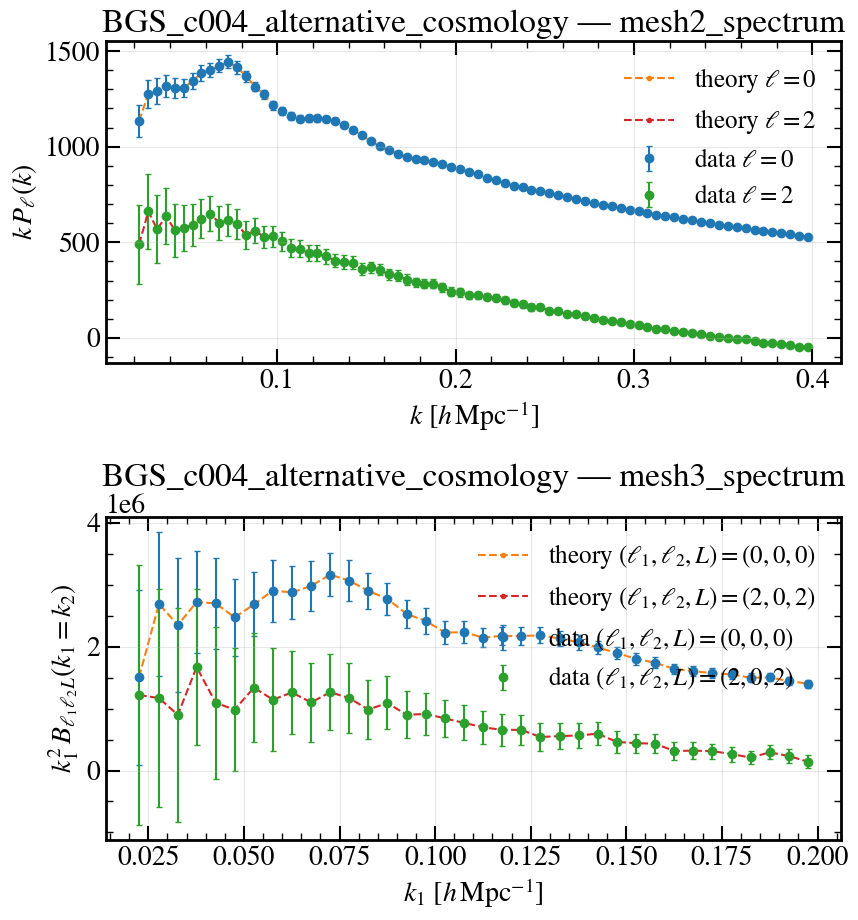

In [22]:
def _ell_to_tex(ell):
    if isinstance(ell, tuple):
        return rf"({','.join(str(x) for x in ell)})"
    return str(ell)


def plot_dataset_comparison(engine, chi2_details, tracer):
    block = [block for block in engine.blocks if block.tracer == tracer][0]
    info = chi2_details[tracer]

    cov_diag = np.asarray(np.diag(block.covariance), dtype=float)
    cov_diag = np.clip(cov_diag, 0.0, None)

    # Per-stat offsets in the flattened data/theory/covariance vectors
    stat_sizes = [flat_value(obj).size for obj in block.data_objects]
    stat_offsets = np.r_[0, np.cumsum(stat_sizes)]

    nstat = len(block.stat_names)
    fig, axes = plt.subplots(nstat, 1, figsize=(9, 4.8 * nstat), squeeze=False)

    for istat, (ax, stat_name, data_obj) in enumerate(
        zip(axes[:, 0], block.stat_names, block.data_objects, strict=True)
    ):
        lo, hi = stat_offsets[istat], stat_offsets[istat + 1]

        data_flat = np.asarray(info['data_vector'][lo:hi], dtype=float)
        theory_flat = np.asarray(info['theory_vector'][lo:hi], dtype=float)
        err_flat = np.sqrt(cov_diag[lo:hi])

        cursor = 0
        for ell in data_obj.ells:
            piece = data_obj.get(ells=ell)
            coords = np.asarray(piece.coords('k'), dtype=float)
            n_piece = np.asarray(piece.values('value'), dtype=float).reshape(-1).size

            y_data = data_flat[cursor:cursor + n_piece]
            y_theory = theory_flat[cursor:cursor + n_piece]
            y_err = err_flat[cursor:cursor + n_piece]
            cursor += n_piece

            if stat_name == 'mesh2_spectrum':
                # Power spectrum: x = k
                x = coords.reshape(-1)
                scale = x
                y_data_plot = scale * y_data
                y_theory_plot = scale * y_theory
                y_err_plot = scale * y_err

                order = np.argsort(x)
                x = x[order]
                y_data_plot = y_data_plot[order]
                y_theory_plot = y_theory_plot[order]
                y_err_plot = y_err_plot[order]

                ell_tex = _ell_to_tex(ell)
                ax.errorbar(
                    x, y_data_plot, yerr=y_err_plot,
                    fmt='o', capsize=2, ls='none',
                    label=rf"data $\ell={ell_tex}$"
                )
                ax.plot(
                    x, y_theory_plot,
                    marker='.', ls='--',
                    label=rf"theory $\ell={ell_tex}$"
                )

                ax.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
                ax.set_ylabel(r"$k\,P_\ell(k)$")

            elif stat_name == 'mesh3_spectrum':
                # Bispectrum: use k1 on the x-axis
                if coords.ndim == 1:
                    x = coords.reshape(-1)
                else:
                    x = coords[:, 0].reshape(-1)   # k1

                scale = x**2
                y_data_plot = scale * y_data
                y_theory_plot = scale * y_theory
                y_err_plot = scale * y_err

                order = np.argsort(x)
                x = x[order]
                y_data_plot = y_data_plot[order]
                y_theory_plot = y_theory_plot[order]
                y_err_plot = y_err_plot[order]

                if isinstance(ell, tuple) and len(ell) == 3:
                    ell_tex = rf"(\ell_1,\ell_2,L)={_ell_to_tex(ell)}"
                else:
                    ell_tex = rf"{_ell_to_tex(ell)}"

                ax.errorbar(
                    x, y_data_plot, yerr=y_err_plot,
                    fmt='o', capsize=2, ls='none',
                    label=rf"data ${ell_tex}$"
                )
                ax.plot(
                    x, y_theory_plot,
                    marker='.', ls='--',
                    label=rf"theory ${ell_tex}$"
                )

                ax.set_xlabel(r"$k_1\ [h\,{\rm Mpc}^{-1}]$")
                ax.set_ylabel(r"$k_1^2\,B_{\ell_1\ell_2L}(k_1=k_2)$")

            else:
                raise NotImplementedError(f"Unsupported statistic: {stat_name}")

        ax.set_title(f"{tracer} — {stat_name}")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    return fig


for dataset in DATASETS:
    plot_dataset_comparison(engine, chi2_details, dataset['name'])
plt.show()

## 11. Where to plug in an external theory

Use the cell below as a template.
The idea is simply to build a dictionary with the same top-level structure as `example_theory`
and then pass it to `engine.chi2(...)`.

In [18]:

# Example skeleton for one external model:
#
# external_theory = {
#     DATASETS[0]['name']: {
#         'mesh2_spectrum': {
#             0: (k_grid, P0_model),
#             2: (k_grid, P2_model),
#         },
#         'mesh3_spectrum': {
#             (0, 0, 0): (coords_2d, B000_model),
#             (2, 0, 2): (coords_2d, B202_model),
#         },
#     }
# }
#
# total_chi2, details = engine.chi2(external_theory)

## 12. How to access data and covariance selected (in case you want to use it outside of the notebook)

In [19]:
def extract_dataset_arrays(engine, tracer):
    block = [block for block in engine.blocks if block.tracer == tracer][0]

    out = {
        'tracer': tracer,
        'data_vector': np.asarray(block.data_vector, dtype=float).copy(),
        'covariance': np.asarray(block.covariance, dtype=float).copy(),
        'precision': np.asarray(block.precision, dtype=float).copy(),
        'stats': {},
    }

    offset = 0
    for stat_name, data_obj in zip(block.stat_names, block.data_objects, strict=True):
        stat_dict = {
            'observable': data_obj,
            'vector': np.asarray(flat_value(data_obj), dtype=float).copy(),
            'covariance': np.asarray(
                block.covariance[offset:offset + flat_value(data_obj).size,
                                 offset:offset + flat_value(data_obj).size],
                dtype=float,
            ).copy(),
            'pieces': {},
        }

        cursor = 0
        for ell in data_obj.ells:
            piece = data_obj.get(ells=ell)

            values = np.asarray(piece.values('value'), dtype=float).reshape(-1)
            n_piece = values.size

            cov_piece = np.asarray(
                block.covariance[offset + cursor:offset + cursor + n_piece,
                                 offset + cursor:offset + cursor + n_piece],
                dtype=float,
            ).copy()

            entry = {
                'values': values.copy(),
                'covariance': cov_piece,
                'sigma': np.sqrt(np.clip(np.diag(cov_piece), 0.0, None)),
            }

            coords = np.asarray(piece.coords('k'), dtype=float)

            if stat_name == 'mesh2_spectrum':
                entry['k'] = coords.reshape(-1).copy()
            elif stat_name == 'mesh3_spectrum':
                entry['kcoords'] = coords.copy()
                entry['k1'] = coords[:, 0].copy()
                entry['k2'] = coords[:, 1].copy()
            else:
                entry['coords'] = coords.copy()

            stat_dict['pieces'][ell] = entry
            cursor += n_piece

        out['stats'][stat_name] = stat_dict
        offset += flat_value(data_obj).size

    return out

In [20]:
dataset_arrays = extract_dataset_arrays(engine, DATASETS[0]['name'])

In [21]:
# Full covariance
C = dataset_arrays['covariance']

# Power spectrum monopole and quadrupole
k0 = dataset_arrays['stats']['mesh2_spectrum']['pieces'][0]['k']
P0 = dataset_arrays['stats']['mesh2_spectrum']['pieces'][0]['values']
C_P0 = dataset_arrays['stats']['mesh2_spectrum']['pieces'][0]['covariance']
sigma_P0 = dataset_arrays['stats']['mesh2_spectrum']['pieces'][0]['sigma']

k2 = dataset_arrays['stats']['mesh2_spectrum']['pieces'][2]['k']
P2 = dataset_arrays['stats']['mesh2_spectrum']['pieces'][2]['values']

# Bispectrum (0,0,0) and (2,0,2)
k1_000 = dataset_arrays['stats']['mesh3_spectrum']['pieces'][(0, 0, 0)]['k1']
k2_000 = dataset_arrays['stats']['mesh3_spectrum']['pieces'][(0, 0, 0)]['k2']
B000 = dataset_arrays['stats']['mesh3_spectrum']['pieces'][(0, 0, 0)]['values']
C_B000 = dataset_arrays['stats']['mesh3_spectrum']['pieces'][(0, 0, 0)]['covariance']

k1_202 = dataset_arrays['stats']['mesh3_spectrum']['pieces'][(2, 0, 2)]['k1']
k2_202 = dataset_arrays['stats']['mesh3_spectrum']['pieces'][(2, 0, 2)]['k2']
B202 = dataset_arrays['stats']['mesh3_spectrum']['pieces'][(2, 0, 2)]['values']

In [22]:
print("Available stats:", list(dataset_arrays['stats']))
for stat, stat_dict in dataset_arrays['stats'].items():
    print(f"\n{stat}")
    for ell, entry in stat_dict['pieces'].items():
        if 'k' in entry:
            print(f"  ell={ell}: len={len(entry['k'])}")
        else:
            print(f"  ell={ell}: len={len(entry['k1'])}, k1 range=({entry['k1'].min():.3f}, {entry['k1'].max():.3f})")

Available stats: ['mesh2_spectrum', 'mesh3_spectrum']

mesh2_spectrum
  ell=0: len=76
  ell=2: len=76

mesh3_spectrum
  ell=(0, 0, 0): len=36, k1 range=(0.023, 0.198)
  ell=(2, 0, 2): len=36, k1 range=(0.023, 0.198)


## 13. Code to save data to share with external collaborators

In [23]:
import json
import h5py
from pathlib import Path


def _ell_to_key(ell):
    """
    Convert an ell label into a safe HDF5 group name.

    Examples
    --------
    0 -> 'ell_0'
    (2, 0, 2) -> 'ell_2_0_2'
    """
    if isinstance(ell, tuple):
        return "ell_" + "_".join(str(x) for x in ell)
    return f"ell_{ell}"


def _ell_to_json(ell):
    """
    Store ell labels losslessly as JSON.
    """
    if isinstance(ell, tuple):
        return json.dumps(list(ell))
    return json.dumps(ell)


def _json_default(obj):
    """
    JSON fallback for numpy scalars/arrays and Path objects.
    """
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    return str(obj)


def _write_dataset(group, name, value, compression=True):
    """
    Write a dataset, replacing an existing dataset with the same name.
    """
    if name in group:
        del group[name]

    value = np.asarray(value)

    if value.shape == ():
        return group.create_dataset(name, data=value)

    if compression:
        return group.create_dataset(
            name,
            data=value,
            compression="gzip",
            compression_opts=4,
            shuffle=True,
        )
    return group.create_dataset(name, data=value)


def _safe_values(obj, name):
    """
    Safely extract obj.values(name). Return None if unavailable.
    """
    try:
        return np.asarray(obj.values(name))
    except Exception:
        return None


def _safe_attrs(obj):
    """
    Convert lsstypes attrs into a JSON-serializable dictionary.
    """
    try:
        return dict(obj.attrs)
    except Exception:
        return {}


def _coord_size(k):
    """
    Number of vector entries represented by a coordinate array.

    For power spectrum, k is usually shape (N,).
    For bispectrum, k is usually shape (N, 2).
    """
    k = np.asarray(k)
    if k.ndim == 0:
        return 1
    return k.shape[0]


def _write_layout_from_observable(parent, name, observable, include_values=False):
    """
    Write per-ell coordinates and slices for an lsstypes observable-like object.

    Parameters
    ----------
    parent : h5py.Group
        Parent group.
    name : str
        Name of layout group to create, e.g. 'data_layout', 'theory_layout'.
    observable : lsstypes object
        Object with .ells and .get(ells=...).
    include_values : bool
        If True, also write the values for each ell and return the concatenated vector.

    Returns
    -------
    vector : np.ndarray or None
        Concatenated values if include_values=True, otherwise None.
    layout : list[dict]
        Python metadata list describing ordering and slices.
    """
    grp = parent.require_group(name)

    layout = []
    pieces = []
    start = 0

    for ell in observable.ells:
        ell_grp = grp.require_group(_ell_to_key(ell))
        leaf = observable.get(ells=ell)

        coords = np.asarray(leaf.coords("k"))
        _write_dataset(ell_grp, "k", coords)

        if coords.ndim == 1:
            coord_names = ["k"]
            _write_dataset(ell_grp, "k1d", coords.reshape(-1))
        elif coords.ndim == 2 and coords.shape[1] == 2:
            coord_names = ["k1", "k2"]
            _write_dataset(ell_grp, "k1", coords[:, 0])
            _write_dataset(ell_grp, "k2", coords[:, 1])
        else:
            coord_names = ["coords"]

        if include_values:
            value = np.asarray(leaf.values("value"), dtype=float).reshape(-1)
            _write_dataset(ell_grp, "value", value)
            n = len(value)
            pieces.append(value)
        else:
            n = _coord_size(coords)

        shotnoise = _safe_values(leaf, "shotnoise")
        if shotnoise is not None:
            _write_dataset(ell_grp, "shotnoise", shotnoise)

        nmodes = _safe_values(leaf, "nmodes")
        if nmodes is not None:
            _write_dataset(ell_grp, "nmodes", nmodes)

        attrs = _safe_attrs(leaf)
        ell_grp.attrs["attrs_json"] = json.dumps(attrs, default=_json_default)
        ell_grp.attrs["ell_json"] = _ell_to_json(ell)
        ell_grp.attrs["coord_names_json"] = json.dumps(coord_names)
        ell_grp.attrs["slice_start"] = int(start)
        ell_grp.attrs["slice_stop"] = int(start + n)

        layout.append({
            "ell": ell,
            "ell_key": _ell_to_key(ell),
            "slice_start": int(start),
            "slice_stop": int(start + n),
            "size": int(n),
            "coords_shape": tuple(np.asarray(coords).shape),
            "coord_names": coord_names,
        })

        start += n

    vector = np.concatenate(pieces) if include_values and pieces else None
    grp.attrs["layout_json"] = json.dumps(layout, default=_json_default)
    grp.attrs["total_size"] = int(start)

    return vector, layout


def _build_data_vector_and_layout(block, tracer_grp):
    """
    Write data arrays for one tracer block and return the full concatenated data vector.
    """
    data_grp = tracer_grp.require_group("data")

    full_pieces = []
    full_layout = []
    global_start = 0

    for stat_name, data_obj in zip(block.stat_names, block.data_objects, strict=True):
        stat_grp = data_grp.require_group(stat_name)
        stat_vector, stat_layout = _write_layout_from_observable(
            stat_grp,
            "ells",
            data_obj,
            include_values=True,
        )

        _write_dataset(stat_grp, "vector", stat_vector)

        for item in stat_layout:
            item = dict(item)
            item["stat"] = stat_name
            item["global_slice_start"] = int(global_start + item["slice_start"])
            item["global_slice_stop"] = int(global_start + item["slice_stop"])
            full_layout.append(item)

        full_pieces.append(stat_vector)
        global_start += len(stat_vector)

    full_vector = np.concatenate(full_pieces)
    _write_dataset(data_grp, "vector", full_vector)
    data_grp.attrs["layout_json"] = json.dumps(full_layout, default=_json_default)
    data_grp.attrs["total_size"] = int(len(full_vector))

    return full_vector, full_layout


def _write_theory_group(tracer_grp, block):
    """
    Write the exact theory layout required by the box chi2 engine.

    For the box case there is no window matrix. External collaborators must
    provide the theory directly on the saved theory grid, in the exact order
    described here.
    """
    theory_grp = tracer_grp.require_group("theory")

    full_layout = []
    global_start = 0

    for stat_name, data_obj in zip(block.stat_names, block.data_objects, strict=True):
        stat_grp = theory_grp.require_group(stat_name)

        # In the box case, theory must be evaluated on the same selected grid
        _, stat_layout = _write_layout_from_observable(
            stat_grp,
            "ells",
            data_obj,
            include_values=False,
        )

        stat_size = sum(item["size"] for item in stat_layout)
        stat_grp.attrs["size"] = int(stat_size)

        for item in stat_layout:
            item = dict(item)
            item["stat"] = stat_name
            item["global_slice_start"] = int(global_start + item["slice_start"])
            item["global_slice_stop"] = int(global_start + item["slice_stop"])
            full_layout.append(item)

        global_start += stat_size

    theory_grp.attrs["layout_json"] = json.dumps(full_layout, default=_json_default)
    theory_grp.attrs["total_size"] = int(global_start)
    theory_grp.attrs["description"] = (
        "For boxes there is no survey window convolution in this export. "
        "External theory vectors must be built directly on the saved theory grid "
        "and concatenated in the exact order described by theory/layout_json."
    )


def _write_covariance_group(tracer_grp, block, data_layout):
    """
    Write the full covariance and precision matrices for one tracer block.

    This full matrix is the authoritative covariance object. It includes:
      - power-power covariance,
      - bispectrum-bispectrum covariance,
      - power-bispectrum cross-covariance,

    in the exact same ordering as /data/vector.
    """
    cov_grp = tracer_grp.require_group("covariance")

    C = np.asarray(block.covariance, dtype=float)
    _write_dataset(cov_grp, "matrix", C)

    P = np.asarray(block.precision, dtype=float)
    _write_dataset(cov_grp, "precision", P)

    cov_grp.attrs["shape"] = json.dumps(tuple(C.shape))
    cov_grp.attrs["data_layout_json"] = json.dumps(data_layout, default=_json_default)
    cov_grp.attrs["covariance_attrs_json"] = json.dumps(
        dict(block.covariance_attrs), default=_json_default
    )
    cov_grp.attrs["precision_info_json"] = json.dumps(
        dict(block.precision_info), default=_json_default
    )

    _write_dataset(cov_grp, "std", np.sqrt(np.clip(np.diag(C), 0.0, None)))


def _write_tracer_metadata(tracer_grp, block):
    """
    Write per-tracer metadata needed by external theory/model codes.

    Stored quantities
    -----------------
    nmean : float
        Number density inferred from the monopole power-spectrum shot noise:
            nmean = 1 / shotnoise_P0[0]
    power_shotnoise : array
        Shot-noise array stored in the power-spectrum monopole data object.
    bispectrum_poisson : array
        Bispectrum Poisson/shot-noise term stored in the B000 data object.
    dataset_config : dict
        Dataset configuration used to build this tracer block.
    """
    meta_grp = tracer_grp.require_group("metadata")

    nmean = np.nan
    power_shotnoise = np.array([], dtype=float)
    bispectrum_poisson = np.array([], dtype=float)

    if "mesh2_spectrum" in block.stat_names:
        i_pow = block.stat_names.index("mesh2_spectrum")
        data_pow = block.data_objects[i_pow]
        try:
            power_shotnoise = np.asarray(
                data_pow.get(ells=0).values("shotnoise"),
                dtype=float,
            )
            nmean = float(1.0 / power_shotnoise.flat[0])
        except Exception:
            power_shotnoise = np.array([], dtype=float)
            nmean = np.nan

    if "mesh3_spectrum" in block.stat_names:
        i_bis = block.stat_names.index("mesh3_spectrum")
        data_bis = block.data_objects[i_bis]
        try:
            bispectrum_poisson = np.asarray(
                data_bis.get(ells=(0, 0, 0)).values("shotnoise"),
                dtype=float,
            )
        except Exception:
            bispectrum_poisson = np.array([], dtype=float)

    _write_dataset(meta_grp, "nmean", np.asarray(nmean))
    _write_dataset(meta_grp, "power_shotnoise", power_shotnoise)
    _write_dataset(meta_grp, "bispectrum_poisson", bispectrum_poisson)

    meta_grp.attrs["dataset_config_json"] = json.dumps(
        dict(block.dataset_config), default=_json_default
    )
    meta_grp.attrs["description"] = (
        "Metadata useful for external model evaluation. "
        "nmean is inferred as 1 / power_shotnoise[0]. "
        "bispectrum_poisson is read from data_bis.get(ells=(0,0,0)).values('shotnoise')."
    )


def export_mockchallenge_chi2_inputs(
    engine,
    filename,
    tracers=None,
    kranges=None,
    description=None,
):
    """
    Export all ingredients needed to compute chi2 outside this notebook.

    Parameters
    ----------
    engine : MockChallengeChi2Engine
        Loaded box mock-challenge engine.
    filename : str or Path
        Output HDF5 filename.
    tracers : list[str] or None
        Dataset names / tracer block names to export. If None, export all blocks.
    kranges : dict or None
        Optional KRANGES dictionary used to select the data.
    description : str or None
        Optional human-readable description stored in the file.

    File structure
    --------------
    /tracers/{tracer}/data/vector
        Full concatenated data vector for that tracer block.

    /tracers/{tracer}/data/{stat}/ells/{ell_key}/k
        Coordinates for that stat/ell in data space.

    /tracers/{tracer}/data/{stat}/ells/{ell_key}/value
        Data values for that stat/ell.

    /tracers/{tracer}/theory/{stat}/ells/{ell_key}/k
        Coordinates describing the exact theory grid expected by the box engine.

    /tracers/{tracer}/covariance/matrix
        Full covariance matrix in the same order as data/vector.

    /tracers/{tracer}/covariance/precision
        Precision matrix in the same order as data/vector.

    Notes
    -----
    The exported covariance matrix is the central object. It preserves all
    cross-covariance between power spectrum and bispectrum bins within a tracer block.
    The current engine treats different tracer blocks as independent likelihood blocks,
    so the total chi2 is the sum over block-level chi2 values.
    """
    filename = Path(filename)

    if tracers is None:
        tracers = [block.tracer for block in engine.blocks]

    blocks_by_tracer = {block.tracer: block for block in engine.blocks}

    with h5py.File(filename, "w") as h5:
        h5.attrs["format"] = "MockChallengeChi2Engine export"
        h5.attrs["version"] = "1.0"
        h5.attrs["description"] = description or (
            "Inputs required to compute chi2 from external theory predictions."
        )
        h5.attrs["stats"] = json.dumps(list(engine.stats))
        h5.attrs["tracers"] = json.dumps(list(tracers))
        h5.attrs["kranges_json"] = json.dumps(kranges, default=_json_default)
        h5.attrs["chi2_formula"] = (
            "For each tracer block: chi2 = (d - m)^T C^{-1} (d - m), "
            "where m is the theory vector built directly on the exported theory grid "
            "and concatenated in theory/data order. "
            "Total chi2 is the sum over tracer blocks."
        )

        tracers_grp = h5.require_group("tracers")

        for tracer in tracers:
            if tracer not in blocks_by_tracer:
                raise KeyError(
                    f"Tracer {tracer} not found in engine. "
                    f"Available: {list(blocks_by_tracer)}"
                )

            block = blocks_by_tracer[tracer]
            tracer_grp = tracers_grp.require_group(tracer)

            tracer_grp.attrs["tracer"] = tracer
            tracer_grp.attrs["stat_names"] = json.dumps(list(block.stat_names))
            tracer_grp.attrs["dataset_config_json"] = json.dumps(
                dict(block.dataset_config), default=_json_default
            )

            data_vector, data_layout = _build_data_vector_and_layout(block, tracer_grp)
            _write_theory_group(tracer_grp, block)
            _write_covariance_group(tracer_grp, block, data_layout)
            _write_tracer_metadata(tracer_grp, block)

            tracer_grp.attrs["ndata"] = int(len(data_vector))
            tracer_grp.attrs["covariance_shape"] = json.dumps(tuple(block.covariance.shape))

    return filename

In [24]:
output_fn = export_mockchallenge_chi2_inputs(
    engine,
    filename=f"alternative_cosmologies/mockchallenge_boxes_alt_cosmo_data_{COSMOLOGY_LABEL}_{TRACER}.h5",
    tracers=[dataset["name"] for dataset in DATASETS],
    kranges=KRANGES,
    description=(
        "Mock-challenge box chi2 inputs for the alternative-cosmology case. "
        "Contains mean high-fidelity measurements, full covariance and precision "
        "from EZmocks, and the exact theory grid required to evaluate chi2."
    ),
)

print(output_fn)

alternative_cosmologies/mockchallenge_boxes_alt_cosmo_data_c004_QSO.h5
